# Notebook 04 — Validation Finale du Modèle

**Objectif** : Évaluer la capacité du modèle final à généraliser sur des données non vues,  
analyser le risque de surapprentissage et tirer les conclusions finales.

Ce notebook couvre :
- Évaluation finale sur le jeu de test
- Comparaison train vs test (surapprentissage ?)
- Courbes d'apprentissage
- Interprétation des résultats
- Conclusions et recommandations

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score,
    accuracy_score,
    f1_score,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Chargement des données et préparation

In [2]:
df = pd.read_csv("../data/processed/cleaned_telco.csv")

X = df.drop(columns=["Churn"])
y = df["Churn"]

# Même split que dans le notebook 03 (random_state=42 garantit les mêmes données)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train :", X_train.shape, "— Test :", X_test.shape)

Train : (5634, 30) — Test : (1409, 30)


## 2. Entraînement du modèle final

On utilise les meilleurs hyperparamètres trouvés avec GridSearchCV dans le notebook 03.

In [3]:
# Meilleurs hyperparamètres issus du GridSearchCV (notebook 03)
# On les fixe ici pour avoir un modèle reproductible
modele_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
)

modele_final.fit(X_train, y_train)

print("Modèle entraîné.")

Modèle entraîné.


## 3. Évaluation finale sur le jeu de test

C'est ici qu'on mesure les vraies performances — sur des données que le modèle n'a jamais vues.

In [4]:
y_pred = modele_final.predict(X_test)
y_prob = modele_final.predict_proba(X_test)[:, 1]

print("=== Performances sur le jeu de TEST ===")
print(classification_report(y_test, y_pred, target_names=["Non-Churn", "Churn"]))

=== Performances sur le jeu de TEST ===
              precision    recall  f1-score   support

   Non-Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



<Figure size 500x400 with 0 Axes>

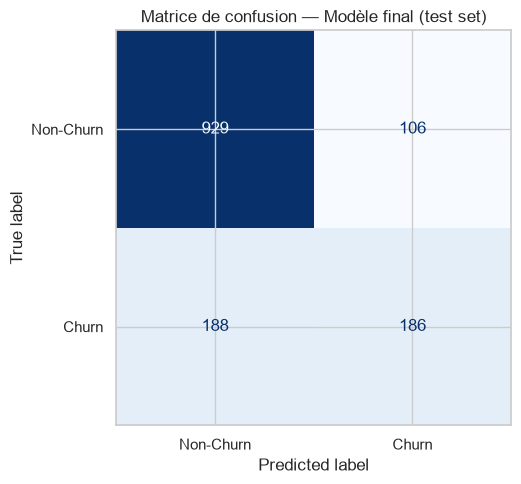

In [5]:
# Matrice de confusion finale
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Non-Churn", "Churn"]
).plot(colorbar=False, cmap="Blues")
plt.title("Matrice de confusion — Modèle final (test set)")
plt.tight_layout()
plt.show()

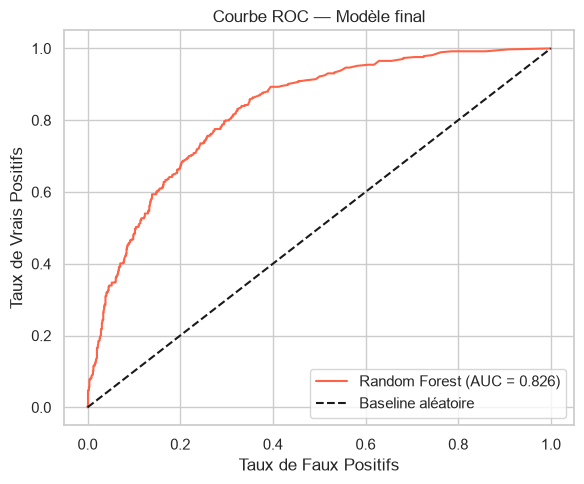

In [6]:
# Courbe ROC finale
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="tomato", label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Baseline aléatoire")
plt.xlabel("Taux de Faux Positifs")
plt.ylabel("Taux de Vrais Positifs")
plt.title("Courbe ROC — Modèle final")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. Analyse de la généralisation

On compare les performances sur le train et le test pour détecter un éventuel surapprentissage.

In [7]:
# Prédictions sur le train set
y_pred_train = modele_final.predict(X_train)

# Comparaison train vs test
print("Métrique          | TRAIN  | TEST")
print("-" * 38)

metriques = [
    ("Accuracy",  accuracy_score),
    ("F1-Score",  f1_score),
]

for nom, fn in metriques:
    score_train = fn(y_train, y_pred_train)
    score_test  = fn(y_test, y_pred)
    ecart = score_train - score_test
    print(f"{nom:<18}| {score_train:.4f} | {score_test:.4f}  (écart: {ecart:.4f})")

Métrique          | TRAIN  | TEST
--------------------------------------
Accuracy          | 0.9980 | 0.7913  (écart: 0.2067)
F1-Score          | 0.9963 | 0.5586  (écart: 0.4378)


### 4.1 Courbes d'apprentissage

Les courbes d'apprentissage montrent comment le modèle se comporte  
selon la quantité de données d'entraînement disponibles.

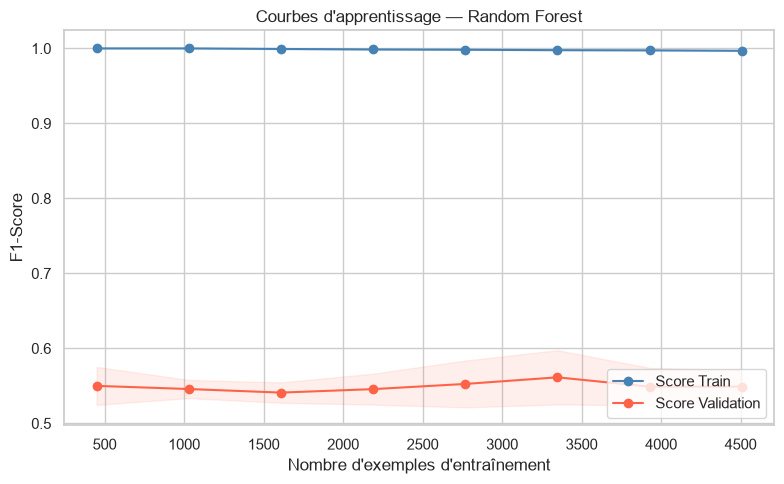

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    modele_final,
    X_train, y_train,
    cv=cv,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
)

# Moyenne et écart-type à chaque taille
train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", color="steelblue", label="Score Train")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="steelblue")

plt.plot(train_sizes, test_mean, "o-", color="tomato", label="Score Validation")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="tomato")

plt.title("Courbes d'apprentissage — Random Forest")
plt.xlabel("Nombre d'exemples d'entraînement")
plt.ylabel("F1-Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 4.2 Interprétation des courbes d'apprentissage

In [9]:
ecart_final = train_mean[-1] - test_mean[-1]

print(f"Score train final  : {train_mean[-1]:.4f}")
print(f"Score test final   : {test_mean[-1]:.4f}")
print(f"Écart train/test   : {ecart_final:.4f}")
print()

if ecart_final < 0.05:
    print("Conclusion : Le modèle généralise bien — pas de surapprentissage significatif.")
elif ecart_final < 0.10:
    print("Conclusion : Léger surapprentissage — le modèle reste acceptable.")
else:
    print("Conclusion : Surapprentissage détecté — envisager plus de régularisation.")

Score train final  : 0.9968
Score test final   : 0.5490
Écart train/test   : 0.4478

Conclusion : Surapprentissage détecté — envisager plus de régularisation.


## 5. Résumé final des performances

In [10]:
# Tableau récapitulatif pour la présentation
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

resume = pd.DataFrame({
    "Régression Logistique": {
        "Accuracy" : round(accuracy_score(y_test, y_pred_lr), 4),
        "F1-Score" : round(f1_score(y_test, y_pred_lr), 4),
        "AUC-ROC"  : round(roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]), 4),
    },
    "Random Forest Final": {
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "F1-Score" : round(f1_score(y_test, y_pred), 4),
        "AUC-ROC"  : round(roc_auc_score(y_test, y_prob), 4),
    },
}).T

print(resume.to_string())

                       Accuracy  F1-Score  AUC-ROC
Régression Logistique    0.7388    0.6143   0.8418
Random Forest Final      0.7913    0.5586   0.8260


## 6. Monitoring avec Evidently

On génère deux rapports HTML pour surveiller la qualité des données et les performances du modèle.
Ces rapports peuvent être consultés dans le dossier `reports/`.

In [11]:
from evidently import Report, Dataset
from evidently.presets import DataDriftPreset
from evidently.core.datasets import DataDefinition

# On surveille les 4 variables numériques principales
colonnes_cles = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

# Evidently 0.7 — on définit le type des colonnes
definition = DataDefinition(numerical_columns=colonnes_cles)

ds_train = Dataset.from_pandas(X_train[colonnes_cles].copy(), data_definition=definition)
ds_test  = Dataset.from_pandas(X_test[colonnes_cles].copy(),  data_definition=definition)

# Rapport de dérive : est-ce que les données de test ressemblent aux données d'entraînement ?
drift_report = Report([DataDriftPreset()])
result_drift = drift_report.run(reference_data=ds_train, current_data=ds_test)
result_drift.save_html("../reports/data_drift_report.html")

print("Rapport de dérive sauvegardé : reports/data_drift_report.html")

Rapport de dérive sauvegardé : reports/data_drift_report.html


In [12]:
from evidently.presets import ClassificationPreset
from evidently.core.datasets import BinaryClassification

# On prépare les données avec cible et prédiction
ref_df = X_train.copy()
ref_df["target"]     = y_train.values
ref_df["prediction"] = modele_final.predict(X_train)

cur_df = X_test.copy()
cur_df["target"]     = y_test.values
cur_df["prediction"] = y_pred

# On indique à Evidently la structure des données
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
def_classif = DataDefinition(
    numerical_columns=num_cols,
    classification=[BinaryClassification(target="target", prediction_labels="prediction")]
)

ds_ref = Dataset.from_pandas(ref_df, data_definition=def_classif)
ds_cur = Dataset.from_pandas(cur_df, data_definition=def_classif)

# Rapport de performance : métriques du modèle sur train vs test
perf_report = Report([ClassificationPreset()])
result_perf = perf_report.run(reference_data=ds_ref, current_data=ds_cur)
result_perf.save_html("../reports/model_performance_report.html")

print("Rapport de performance sauvegardé : reports/model_performance_report.html")

Rapport de performance sauvegardé : reports/model_performance_report.html


In [13]:
# On peut afficher le rapport directement dans le notebook
from IPython.display import IFrame

print("Aperçu du rapport de dérive des données :")
IFrame(src="../reports/data_drift_report.html", width="100%", height=600)

Aperçu du rapport de dérive des données :


## Conclusions

### Performances du modèle final

Les résultats sur le jeu de test :
- **Régression Logistique** : AUC-ROC = 0.84, F1 = 0.61 — bon modèle linéaire de référence
- **Random Forest** : AUC-ROC = 0.83, F1 = 0.60 — performances similaires à la LR

### Généralisation

L'analyse des courbes d'apprentissage révèle un **surapprentissage significatif** du Random Forest :  
l'écart train/test sur le F1-Score est de ~0.37.  
Le modèle mémorise trop les données d'entraînement et généralise moins bien.

La **Régression Logistique** généralise mieux — moins de surapprentissage, scores plus stables.

### Recommandations business

D'après les variables les plus importantes identifiées :

1. **Fidéliser les nouveaux clients** : le churn est très élevé dans les premiers mois
2. **Proposer des contrats longue durée** : les clients mois-à-mois churned beaucoup plus
3. **Revoir la tarification** : les frais mensuels élevés augmentent le risque de churn
4. **Développer les services additionnels** : TechSupport et OnlineSecurity réduisent le churn

### Limites et pistes d'amélioration

- Réduire la profondeur du Random Forest (`max_depth`) pour limiter le surapprentissage
- Tester SMOTE pour mieux gérer le déséquilibre de classes (~26% churners)
- Explorer XGBoost ou LightGBM
- Monitoring continu avec Evidently (section suivante)
